\# SURSHOP \- Análisis de Rentabilidad

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# CELDA 0 - con los nombres exactos de tu screenshot
import pandas as pd

clientes = pd.read_csv('Clientes.csv')
detalle = pd.read_csv('Detalle-Pedidos.csv')
pedidos = pd.read_csv('Pedidos (1).csv')
productos = pd.read_csv('Productos (1).csv')

print("Cargado OK")
print(f"clientes: {len(clientes)}, productos: {len(productos)}, pedidos: {len(pedidos)}")

Cargado OK
clientes: 500, productos: 7, pedidos: 1200


In [3]:
clientes.head(10)

productos

pedidos.head()

detalle.head()

,pedido_id,producto_id,cantidad,precio_unitario
0,1,7,2,19000
1,2,4,1,320000
2,3,6,1,28000
3,3,4,2,320000
4,3,2,2,149000


Margen total por categoría (solo Entregados):


categoria
Abrigos       13560000
Tablas        12880000
Remeras        3453000
Bermudas       1648000
Accesorios      931000
Name: margen, dtype: int64

<Axes: xlabel='categoria'>

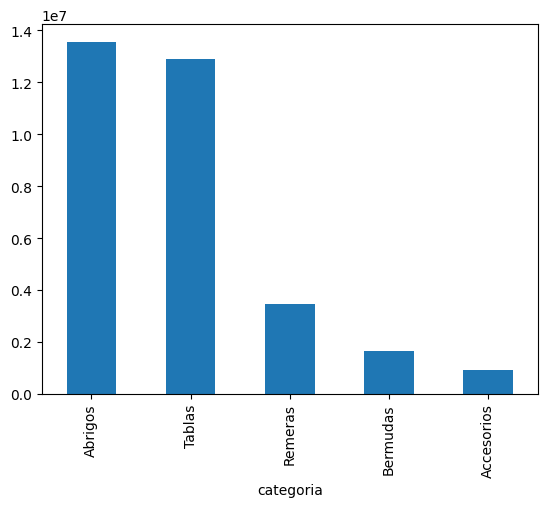

In [4]:
# Junta detalle + productos + estado del pedido
df = detalle.merge(productos, on='producto_id').merge(pedidos[['pedido_id','estado']], on='pedido_id')

# Solo lo que realmente se entregó - lo cancelado no deja margen
df_entregado = df[df['estado'] == 'Entregado'].copy()
df_entregado['margen'] = (df_entregado['precio'] - df_entregado['costo']) * df_entregado['cantidad']

margen_categoria = df_entregado.groupby('categoria')['margen'].sum().sort_values(ascending=False)

print("Margen total por categoría (solo Entregados):")
display(margen_categoria)

# Si querés verlo en gráfico
margen_categoria.plot(kind='bar')

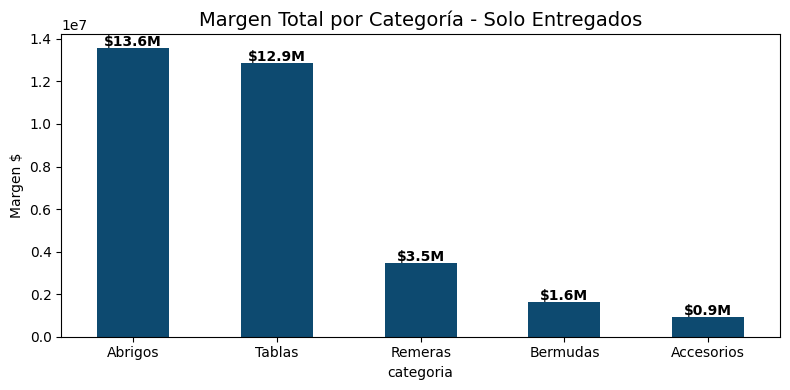

In [5]:
import matplotlib.pyplot as plt

ax = margen_categoria.plot(kind='bar', color='#0d4a70', figsize=(8,4))
plt.title('Margen Total por Categoría - Solo Entregados', fontsize=14)
plt.ylabel('Margen $')
plt.xticks(rotation=0)
for i, v in enumerate(margen_categoria):
    ax.text(i, v + 100000, f"${v/1e6:.1f}M", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

estado,Cancelado,Entregado
canal,,
Marketplace,0.259016,0.262295
Tienda MDP,0.249169,0.312292
Instagram,0.228477,0.264901
Web,0.205479,0.239726


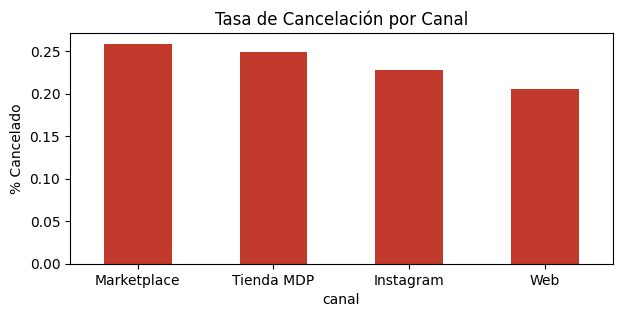

In [6]:
# Tasa de cancelación por canal
cancel = pedidos.groupby('canal')['estado'].value_counts(normalize=True).unstack().fillna(0)

# Ordenamos por % Cancelado de mayor a menor
if 'Cancelado' in cancel.columns:
    display(cancel[['Cancelado','Entregado']].sort_values('Cancelado', ascending=False))
    
    # Para gráfico
    cancel['Cancelado'].sort_values(ascending=False).plot(kind='bar', color='#c0392b', figsize=(7,3))
    plt.title('Tasa de Cancelación por Canal')
    plt.ylabel('% Cancelado')
    plt.xticks(rotation=0)
    plt.show()
else:
    print("No hay cancelados en este corte")

In [7]:
# Qué se cancela por canal y categoría
df_cancel = detalle.merge(productos, on='producto_id').merge(pedidos[['pedido_id','estado','canal']], on='pedido_id')
df_cancel[df_cancel['estado']=='Cancelado'].groupby(['canal','categoria']).size().unstack().fillna(0)

categoria,Abrigos,Accesorios,Bermudas,Remeras,Tablas
canal,,,,,
Instagram,35,16,16,28,18
Marketplace,38,20,23,23,23
Tienda MDP,39,20,15,48,12
Web,28,14,21,20,19


In [10]:
# RE-ARMAMOS df_entregado con cliente_id y fecha
df_entregado = detalle.merge(productos, on='producto_id').merge(
    pedidos[['pedido_id','cliente_id','estado','fecha']], on='pedido_id'
)
df_entregado = df_entregado[df_entregado['estado']=='Entregado'].copy()
df_entregado['margen'] = (df_entregado['precio'] - df_entregado['costo']) * df_entregado['cantidad']

# Ahora sí - cliente + cuánto margen nos dejó + última compra
cliente_valor = df_entregado.groupby('cliente_id').agg(
    pedidos_entregados=('pedido_id','count'),
    margen_total=('margen','sum'),
    ultima_fecha=('fecha','max')
).sort_values('margen_total', ascending=False)

display(cliente_valor.head(10))

,pedidos_entregados,margen_total,ultima_fecha
cliente_id,,,
90,3,576000,2026-08-28
204,6,541000,2026-08-25
245,4,524000,2026-08-15
470,6,518000,2026-08-23
126,6,494000,2026-07-29
91,5,484000,2026-08-19
407,3,458000,2026-07-09
427,3,438000,2026-07-11
111,2,418000,2026-08-15


In [12]:
# Qué compraban los que se fueron
clientes_churn = [407, 427]
df_churn = df_entregado[df_entregado['cliente_id'].isin(clientes_churn)]
display(df_churn.groupby(['cliente_id','categoria'])['margen'].sum())

# Y unilos con su segmento para el mail
display(clientes[clientes['cliente_id'].isin(clientes_churn)])

cliente_id  categoria
407         Abrigos      138000
            Remeras       40000
            Tablas       280000
427         Abrigos      138000
            Remeras       20000
            Tablas       280000
Name: margen, dtype: int64

,cliente_id,nombre,ciudad,provincia,segmento,fecha_alta
406,407,Cliente 407,La Plata,Buenos Aires,Recurrente,2026-04-10
426,427,Cliente 427,Tandil,Buenos Aires,Recurrente,2025-04-08
